Using device: cuda
Local dir: ./ipd_ochr_results
FULL RUN  |  Episodes=3000  Seeds=10
  IPD — OCHR Ablation Study
  N_EPISODES=5000  EVAL=100  SEEDS=10
  OCHR: inject every 3 eps, 8 rollouts, noise=0.05, TD weight=2.5x

Checking Bayesian belief calibration...
  Opponent Family    Mean P(true fam)      Std
  ──────────────────────────────────────────────
  AllC                          1.000    0.000
  AllD                          0.499    0.499
  Retaliation                   0.423    0.488
  Forgiving                     0.525    0.460
  Stochastic                    0.387    0.285
  Cycler                        0.316    0.276
  Prober                        0.000    0.000

Running rule-based baselines...
  Strategy    Seen Comp  Unseen Comp   Seen MC  Unseen MC
  ──────────────────────────────────────────────────────
  tft             1.427        1.285     0.527      0.492
  allc            1.140        1.299     0.628      0.660
  alld            0.400        0.395     0.000     

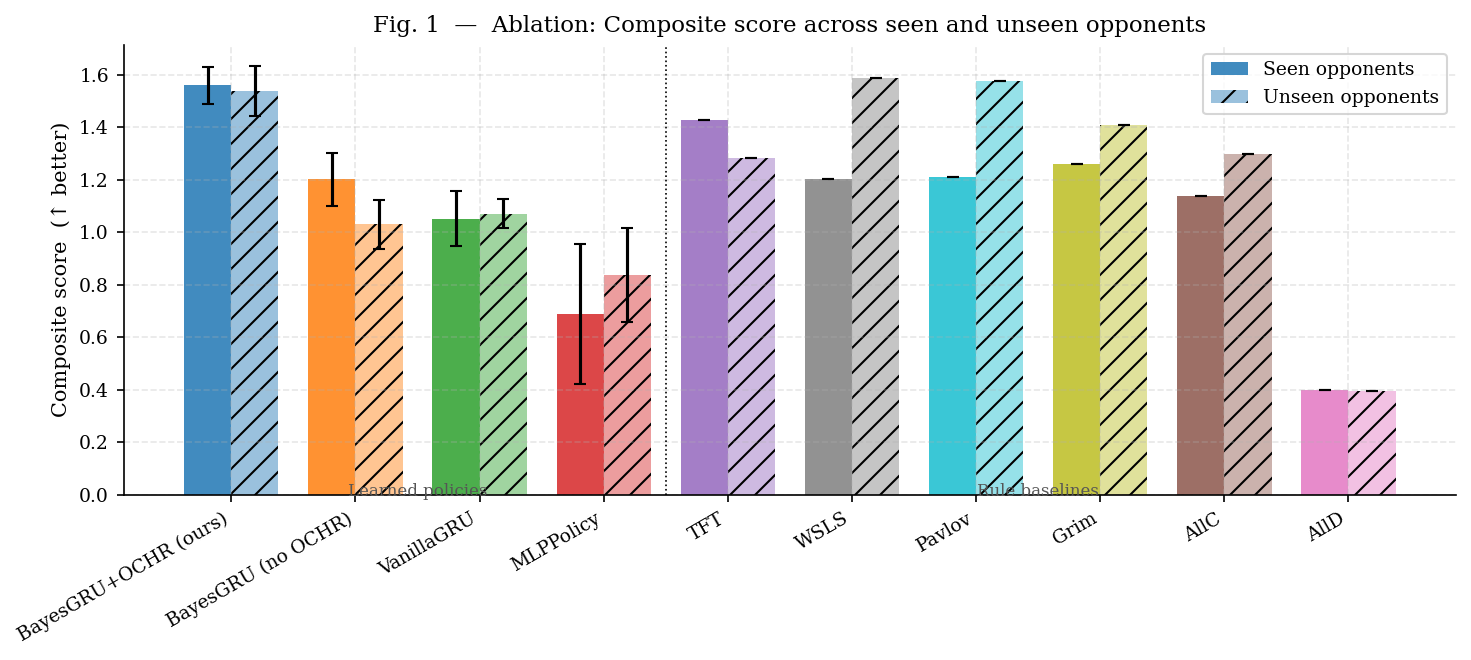

  ✓ fig1_ablation_composite


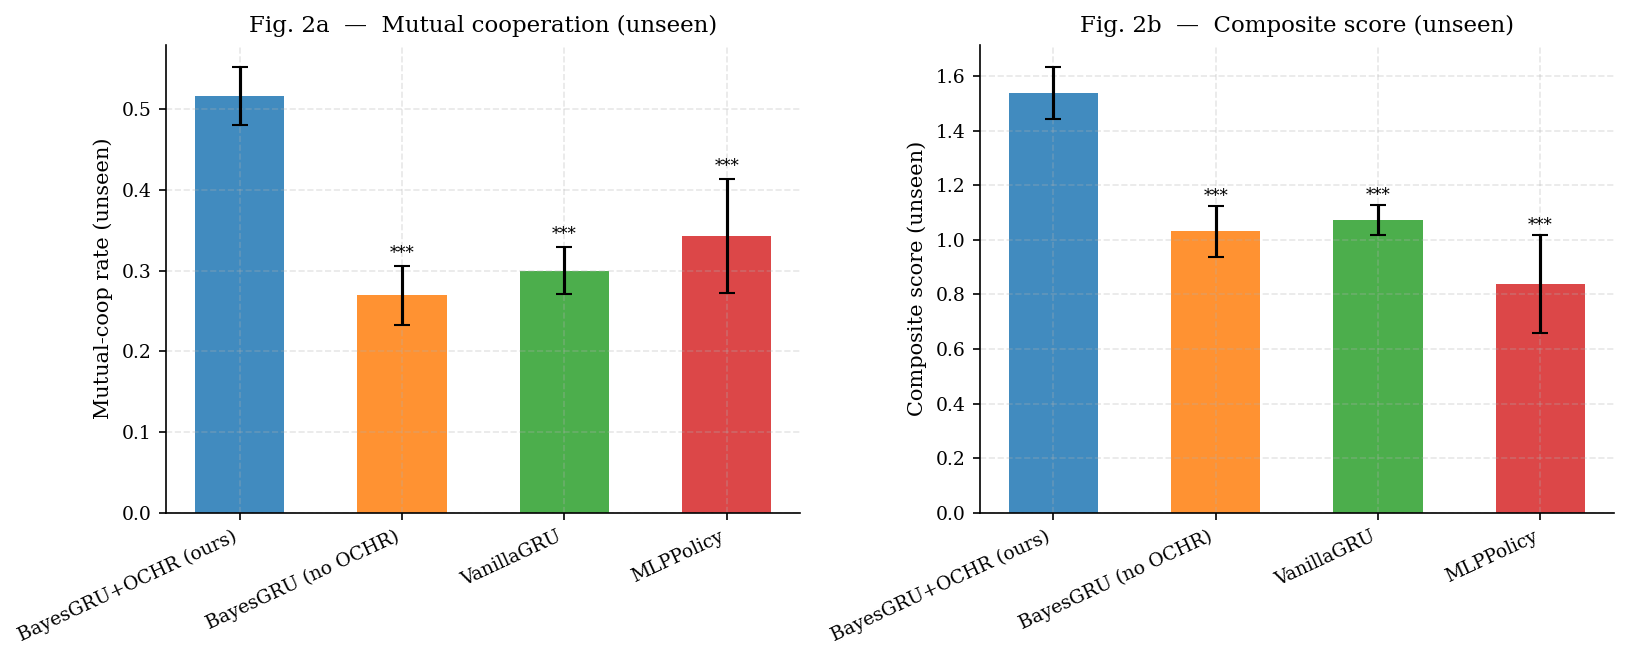

  ✓ fig2_unseen_metrics


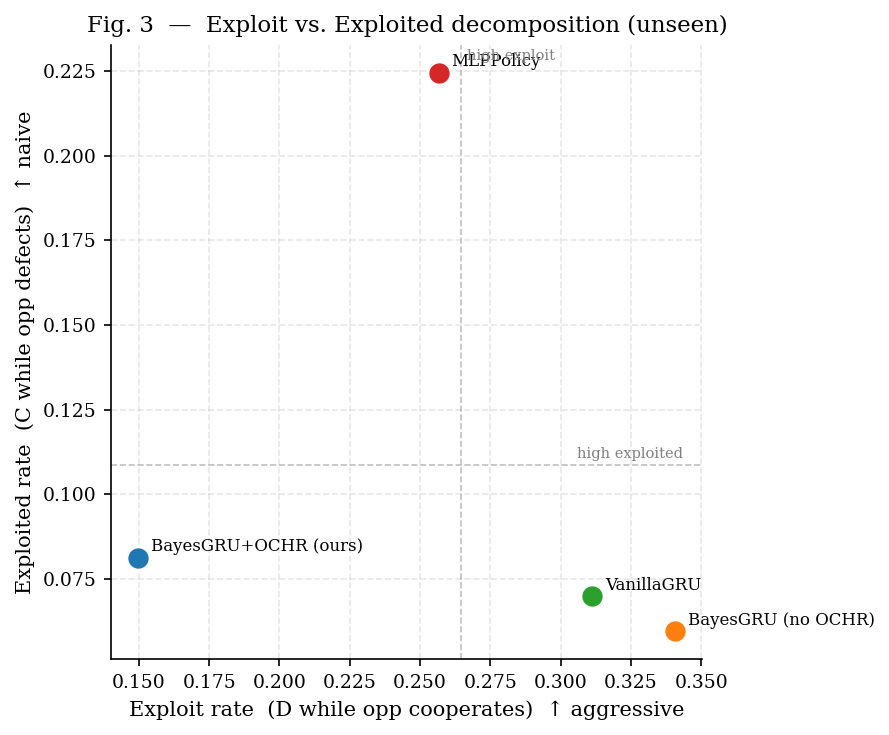

  ✓ fig3_exploit_decomp


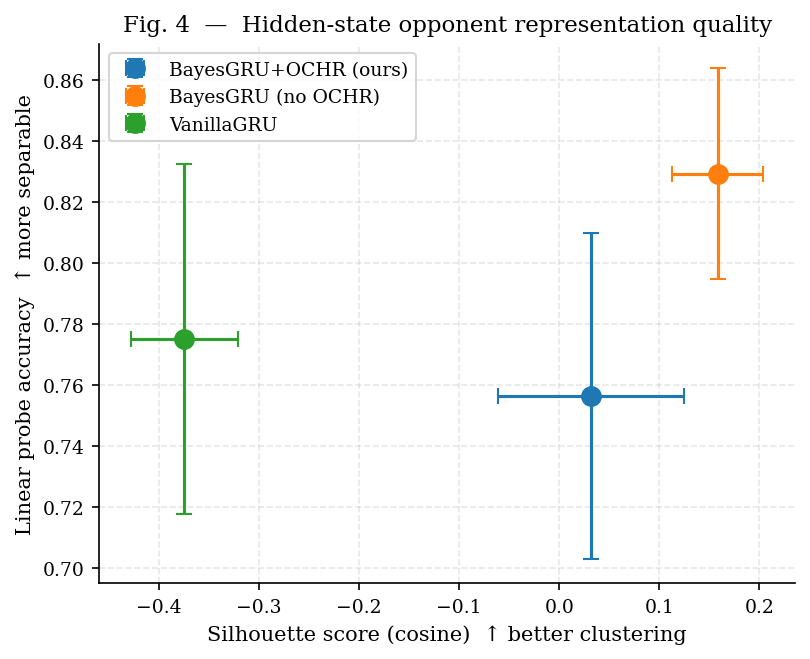

  ✓ fig4_representation


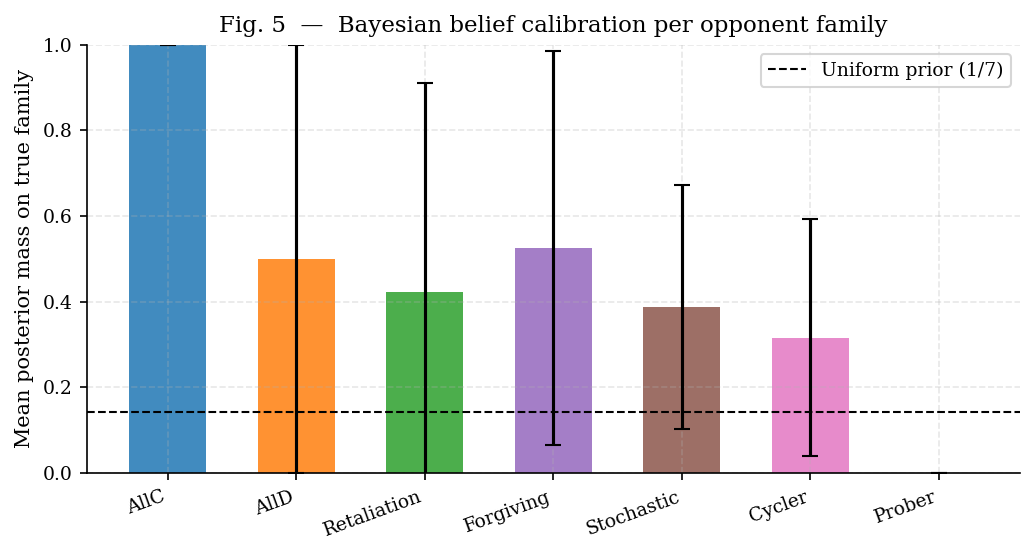

  ✓ fig5_belief_calibration


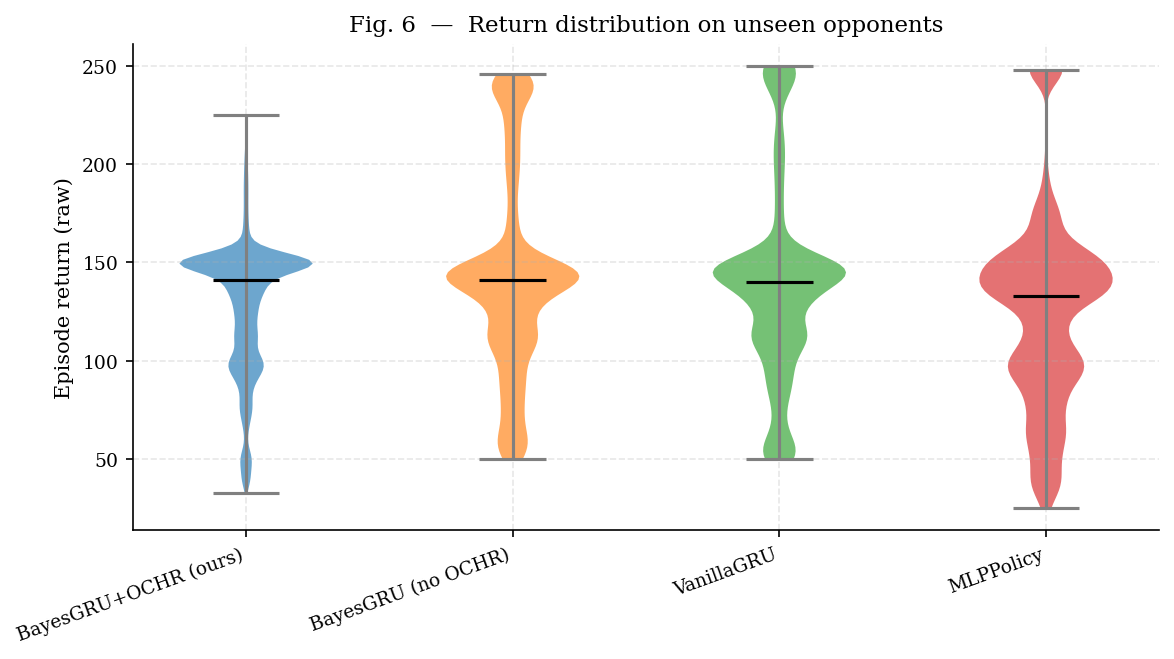

  ✓ fig6_violin_unseen


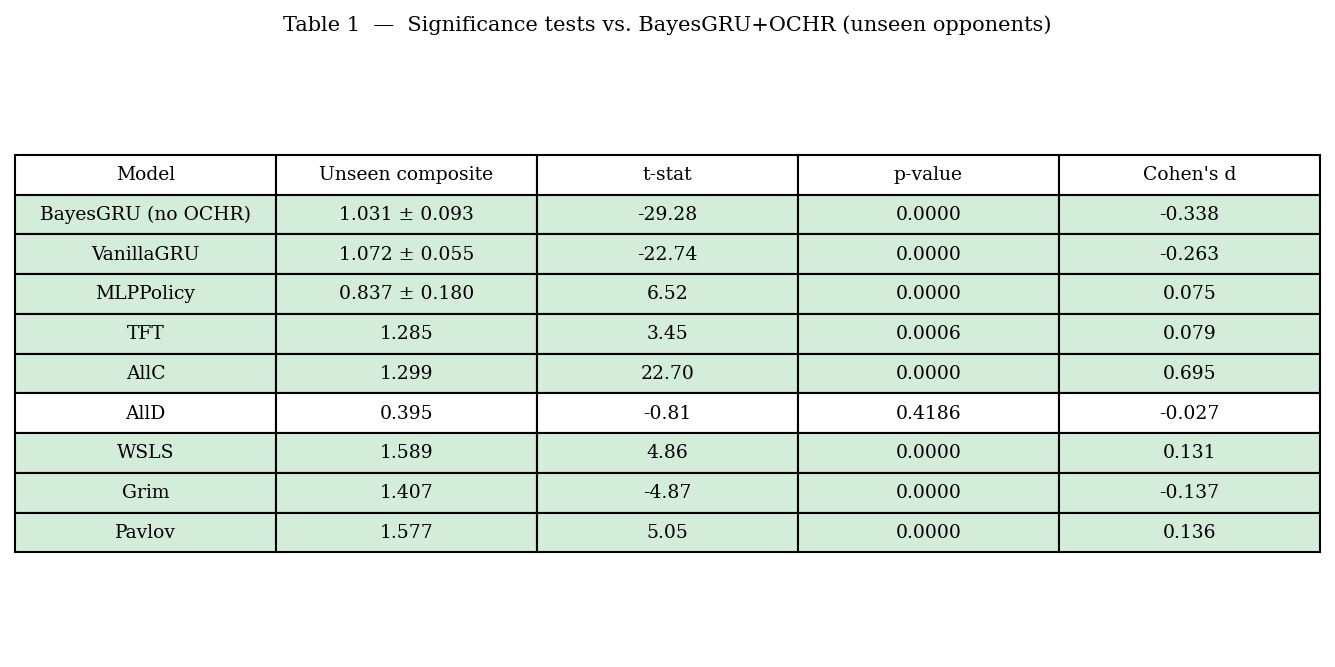

  ✓ table1_significance

  All figures saved to:  ./ipd_ochr_results
  Formats: .pdf (print) + .png (preview)


In [1]:
import collections
import math
import os
import random
import time
import warnings

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from matplotlib.lines import Line2D
from scipy import stats
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

try:
    from google.colab import drive
    drive.mount('/content/drive')
    SAVE_DIR = "/content/drive/MyDrive/ipd_ochr_results"
    os.makedirs(SAVE_DIR, exist_ok=True)
    print(f"Google Drive: {SAVE_DIR}")
except Exception:
    SAVE_DIR = "./ipd_ochr_results"
    os.makedirs(SAVE_DIR, exist_ok=True)
    print(f"Local dir: {SAVE_DIR}")

C, D = 0, 1
PAYOFF = {(0, 0): 3, (0, 1): 0, (1, 0): 5, (1, 1): 1}

FAM_ALLC, FAM_ALLD, FAM_RETALIA, FAM_FORGING = 0, 1, 2, 3
FAM_STOCH, FAM_CYCLER, FAM_PROBER = 4, 5, 6
N_FAMILIES = 7
FAM_NAMES = {
    0: "AllC", 1: "AllD", 2: "Retaliation",
    3: "Forgiving", 4: "Stochastic", 5: "Cycler", 6: "Prober"
}

TRAIN_OPPONENTS = [
    ("allc",           "AllC",        FAM_ALLC),
    ("alld",           "AllD",        FAM_ALLD),
    ("tft",            "TFT",         FAM_RETALIA),
    ("grim",           "Grim",        FAM_RETALIA),
    ("suspicious_tft", "SusTFT",      FAM_RETALIA),
    ("gradual",        "Gradual",     FAM_RETALIA),
    ("soft_grudger",   "SoftGrudger", FAM_RETALIA),
    ("wsls",           "WSLS",        FAM_FORGING),
    ("pavlov",         "Pavlov",      FAM_FORGING),
    ("firm_but_fair",  "FirmFair",    FAM_FORGING),
    ("rand_0.1",       "Rand10",      FAM_STOCH),
    ("rand_0.3",       "Rand30",      FAM_STOCH),
    ("rand_0.5",       "Rand50",      FAM_STOCH),
    ("rand_0.7",       "Rand70",      FAM_STOCH),
    ("rand_0.9",       "Rand90",      FAM_STOCH),
    ("noisy_tft",      "NoisyTFT",    FAM_STOCH),
    ("alternator",     "Alternator",  FAM_CYCLER),
    ("cycler_ccd",     "CyclerCCD",   FAM_CYCLER),
    ("cycler_cccd",    "CyclerCCCD",  FAM_CYCLER),
    ("cycler_dddc",    "CyclerDDDC",  FAM_CYCLER),
    ("hardprober",     "HardProber",  FAM_PROBER),
    ("exploiter",      "Exploiter",   FAM_PROBER),
    ("bully",          "Bully",       FAM_PROBER),
    ("naive_prober",   "NaiveProber", FAM_PROBER),
    ("calculator",     "Calculator",  FAM_PROBER),
]

TEST_OPPONENTS = [
    ("contrite_tft",       "ContriteTFT",      FAM_RETALIA),
    ("memory2_cddc",       "Mem2CDDC",         FAM_RETALIA),
    ("punisher",           "Punisher",         FAM_ALLD),
    ("tft2",               "TitFor2Tats",      FAM_FORGING),
    ("omega_tft",          "OmegaTFT",         FAM_FORGING),
    ("rand_0.2",           "Rand20",           FAM_STOCH),
    ("rand_0.4",           "Rand40",           FAM_STOCH),
    ("rand_0.6",           "Rand60",           FAM_STOCH),
    ("rand_0.8",           "Rand80",           FAM_STOCH),
    ("random_tft",         "RandomTFT",        FAM_STOCH),
    ("cycler_dc",          "CyclerDC",         FAM_CYCLER),
    ("cycler_ddc",         "CyclerDDC",        FAM_CYCLER),
    ("double_prober",      "DoubleProber",     FAM_PROBER),
    ("remorseful_prober",  "RemorsefulProber", FAM_PROBER),
    ("cooperating_killer", "CoopKiller",       FAM_PROBER),
]

OPP_FAMILY = {k: f for k, _, f in TRAIN_OPPONENTS + TEST_OPPONENTS}


class Cfg:
    ROUNDS_PER_EP      = 50
    INPUT_DIM          = 2
    HIDDEN_DIM         = 192
    EMBED_DIM          = 96
    BELIEF_PROJ_DIM    = 32
    BATCH_SIZE         = 48
    GAMMA              = 0.99
    LR                 = 2e-4
    EPS_START          = 1.0
    EPS_END            = 0.05
    BUFFER_SIZE        = 6000
    TARGET_UPDATE      = 150
    GRAD_CLIP          = 0.5
    USE_DDQN           = True
    SEQ_BURNIN         = 10
    BAYES_DIM          = N_FAMILIES
    NUM_GRU_LAYERS     = 2
    DROPOUT            = 0.10
    AUX_LOSS_WEIGHT    = 0.30
    LABEL_SMOOTH       = 0.05
    SIG_WINDOW         = 8
    OCHR_INJECT_EVERY  = 3
    OCHR_NOISE_PROB    = 0.05
    OCHR_ROLLOUTS      = 8
    ORACLE_TD_WEIGHT   = 2.5
    VI_SAMPLES         = 12


class IPDEnv:
    def __init__(self, key: str):
        self.key          = key
        self.family_label = OPP_FAMILY.get(key, FAM_STOCH)
        self.round        = 0
        self.my_history: list = []
        self.op_history: list = []
        self._init_state()

    def _init_state(self):
        n = self.key
        if n.startswith("rand_"):
            self._cp = float(n.split("_")[1])
        self._triggered      = False
        self._defect_mode    = False
        self._bully_coop     = False
        self._contrite       = False
        self._last_op_def    = False
        self._rem_accidental = False
        self._consec_dd      = 0
        self._defect_budget  = 0
        self._punishing      = 0
        self._grudge_count   = 0
        self._coop_count     = 0
        self._defect_count   = 0
        self._calc_mode      = None
        self._mode2          = None
        self._cycle          = []
        self._probe          = []
        self._probe2         = []
        self._probe_seq      = []
        if n == "cycler_ccd":    self._cycle = [C, C, D]
        elif n == "cycler_cccd": self._cycle = [C, C, C, D]
        elif n == "cycler_dddc": self._cycle = [D, D, D, C]
        elif n == "cycler_dc":   self._cycle = [D, C]
        elif n == "cycler_ddc":  self._cycle = [D, D, C]
        if n == "hardprober":    self._probe = [D, D, C, C]
        if n == "double_prober": self._probe2 = [D, C, D, C]
        if n == "calculator":    self._probe_seq = [C, C, D, C, D, D, C, D]
        self._switch_round = random.randint(5, 20)

    def reset(self):
        self.round = 0
        self.my_history = []
        self.op_history = []
        self._init_state()
        return np.array([C, C], dtype=np.float32)

    def _get_op_action(self, my_action):
        n = self.key
        r = self.round
        if n == "allc":  return C
        if n == "alld":  return D
        if n == "tft":   return C if r == 0 else self.my_history[-1]
        if n == "suspicious_tft": return D if r == 0 else self.my_history[-1]
        if n == "tft2":
            if r < 2: return C
            return D if (self.my_history[-1] == D and self.my_history[-2] == D) else C
        if n == "grim":
            if self._triggered: return D
            if r > 0 and self.my_history[-1] == D: self._triggered = True; return D
            return C
        if n == "punisher":
            if self._triggered: return D
            if r > 0 and self.my_history[-1] == D: self._triggered = True; return D
            return C
        if n == "wsls":
            if r == 0: return C
            lp = PAYOFF[(self.op_history[-1], self.my_history[-1])]
            return self.op_history[-1] if lp >= 3 else (D if self.op_history[-1] == C else C)
        if n == "pavlov":
            if r == 0: return C
            return C if self.my_history[-1] == self.op_history[-1] else D
        if n == "gradual":
            if self._punishing > 0: self._punishing -= 1; return D
            if r > 0 and self.my_history[-1] == D:
                self._defect_budget += 1; self._punishing = self._defect_budget - 1; return D
            return C
        if n == "firm_but_fair":
            if r == 0: return C
            if self.my_history[-1] == D and self.op_history[-1] == D: self._consec_dd += 1
            else: self._consec_dd = 0
            return D if self._consec_dd >= 2 else C
        if n == "noisy_tft":
            base = C if r == 0 else self.my_history[-1]
            return 1 - base if random.random() < 0.10 else base
        if n == "contrite_tft":
            if r == 0: return C
            if self._contrite: self._contrite = False; return C
            if self._last_op_def: return D
            return C
        if n == "omega_tft":
            if r == 0: return C
            self._coop_count  += (1 if my_action == C else 0)
            self._defect_count += (1 if my_action == D else 0)
            diff = self._coop_count - self._defect_count
            if diff > 3:  return C
            if diff < -3: return D
            return self.my_history[-1]
        if n == "memory2_cddc":
            if r < 2: return C
            return D if (self.my_history[-2] == C and self.my_history[-1] == D) else C
        if n == "random_tft":
            if r < self._switch_round:
                return C if r == 0 else self.my_history[-1]
            return C if random.random() < 0.5 else D
        if n.startswith("rand_"): return C if random.random() < self._cp else D
        if n == "alternator":     return [C, D][r % 2]
        if n in ("cycler_ccd", "cycler_cccd", "cycler_dddc", "cycler_dc", "cycler_ddc"):
            return self._cycle[r % len(self._cycle)]
        if n == "hardprober":
            if r < 4: return self._probe[r]
            if len(self.my_history) >= 4 and self.my_history[2] == C and self.my_history[3] == C:
                return D
            return self.my_history[-1] if self.my_history else C
        if n == "exploiter":
            if r < 6: return C
            if not self._defect_mode:
                if sum(1 for a in self.my_history[:6] if a == C) >= 4:
                    self._defect_mode = True
            return D if self._defect_mode else C
        if n == "bully":
            if self._bully_coop: return C
            if r > 0 and self.my_history[-1] == D: self._bully_coop = True; return C
            return D
        if n == "naive_prober":
            base = C if r == 0 else self.my_history[-1]
            return D if random.random() < 0.10 else base
        if n == "soft_grudger":
            if self._punishing > 0: self._punishing -= 1; return D
            if r > 0 and self.my_history[-1] == D:
                self._grudge_count += 1; self._punishing = 3; return D
            return C
        if n == "calculator":
            if r < 8: return self._probe_seq[r]
            if self._calc_mode is None:
                pd_ = sum(1 for a in self.my_history[:8] if a == D)
                self._calc_mode = "alld" if pd_ < 2 else "tft"
            return D if self._calc_mode == "alld" else self.my_history[-1]
        if n == "double_prober":
            if r < 4: return self._probe2[r]
            if self._mode2 is None:
                cb = sum(1 for a in self.my_history[:4] if a == C)
                self._mode2 = "alld" if cb >= 3 else "tft"
            return D if self._mode2 == "alld" else (self.my_history[-1] if self.my_history else C)
        if n == "remorseful_prober":
            if r == 0: return C
            base = self.my_history[-1]
            if not self._rem_accidental and random.random() < 0.10:
                self._rem_accidental = True; return D
            if self._rem_accidental: self._rem_accidental = False; return C
            return base
        if n == "cooperating_killer":
            return C if r < Cfg.ROUNDS_PER_EP // 2 else D
        return C

    def step(self, my_action):
        op_action = self._get_op_action(my_action)
        self.my_history.append(my_action)
        self.op_history.append(op_action)
        if self.key == "contrite_tft":
            self._last_op_def = (op_action == D)
            if my_action == D and op_action == C:
                self._contrite = True
        reward = PAYOFF[(my_action, op_action)]
        obs    = np.array([float(my_action), float(op_action)], dtype=np.float32)
        self.round += 1
        done = self.round >= Cfg.ROUNDS_PER_EP
        return obs, reward, done, op_action

    def clone_state(self):
        c = IPDEnv.__new__(IPDEnv)
        c.key           = self.key
        c.family_label  = self.family_label
        c.round         = self.round
        c.my_history    = list(self.my_history)
        c.op_history    = list(self.op_history)
        c._triggered    = self._triggered
        c._defect_mode  = self._defect_mode
        c._bully_coop   = self._bully_coop
        c._contrite     = self._contrite
        c._last_op_def  = self._last_op_def
        c._rem_accidental = self._rem_accidental
        c._consec_dd    = self._consec_dd
        c._defect_budget = self._defect_budget
        c._punishing    = self._punishing
        c._grudge_count = self._grudge_count
        c._coop_count   = self._coop_count
        c._defect_count = self._defect_count
        c._calc_mode    = self._calc_mode
        c._mode2        = self._mode2
        c._cycle        = list(self._cycle)
        c._probe        = list(self._probe)
        c._probe2       = list(self._probe2)
        c._probe_seq    = list(self._probe_seq)
        c._switch_round = self._switch_round
        if hasattr(self, '_cp'):
            c._cp = self._cp
        return c


def _greedy_rollout_from(env: IPDEnv, gamma: float) -> float:
    total = 0.0
    g     = 1.0
    for _ in range(Cfg.ROUNDS_PER_EP - env.round):
        snap_c = env.clone_state()
        snap_d = env.clone_state()
        r_c    = PAYOFF[(C, snap_c._get_op_action(C))]
        r_d    = PAYOFF[(D, snap_d._get_op_action(D))]
        action = C if r_c >= r_d else D
        _, reward, done, _ = env.step(action)
        total += g * reward
        g     *= gamma
        if done:
            break
    return total


def oracle_value_iteration(env_key: str) -> list:
    results = []
    for _ in range(Cfg.VI_SAMPLES):
        env = IPDEnv(env_key)
        env.reset()
        actions = []
        for _ in range(Cfg.ROUNDS_PER_EP):
            snap_c = env.clone_state()
            snap_d = env.clone_state()
            op_c   = snap_c._get_op_action(C)
            op_d   = snap_d._get_op_action(D)
            snap_c.step(C)
            snap_d.step(D)
            val_c  = PAYOFF[(C, op_c)] + Cfg.GAMMA * _greedy_rollout_from(snap_c, Cfg.GAMMA)
            val_d  = PAYOFF[(D, op_d)] + Cfg.GAMMA * _greedy_rollout_from(snap_d, Cfg.GAMMA)
            action = C if val_c >= val_d else D
            env.step(action)
            actions.append(action)
        results.append(actions)
    return results


class RunningNorm:
    def __init__(self, eps=1e-4):
        self.reset(eps)

    def reset(self, eps=1e-4):
        self.n = 0; self.mu = 0.0; self.M2 = 1.0; self.eps = eps

    def update(self, x):
        self.n    += 1
        delta      = x - self.mu
        self.mu   += delta / self.n
        self.M2   += delta * (x - self.mu)

    @property
    def std(self):
        return math.sqrt(self.M2 / max(self.n - 1, 1) + self.eps)

    def normalise(self, x):
        return (x - self.mu) / self.std


Episode = collections.namedtuple(
    "Episode",
    ["obs_seq", "actions", "rewards", "family_label",
     "op_actions", "bayes_seq", "sig_seq", "is_oracle"]
)


class EpisodeReplayBuffer:
    def __init__(self, cap=Cfg.BUFFER_SIZE):
        self.buf = collections.deque(maxlen=cap)

    def push(self, ep):
        self.buf.append(ep)

    def sample(self, n):
        return random.sample(self.buf, min(n, len(self.buf)))

    def __len__(self):
        return len(self.buf)


_P_COOP = {
    (C, C): np.array([1.00, 0.00, 0.95, 0.92, 0.55, 0.50, 0.20], dtype=np.float32),
    (C, D): np.array([1.00, 0.00, 0.08, 0.45, 0.45, 0.50, 0.70], dtype=np.float32),
    (D, C): np.array([1.00, 0.00, 0.30, 0.65, 0.55, 0.50, 0.55], dtype=np.float32),
    (D, D): np.array([1.00, 0.00, 0.02, 0.20, 0.45, 0.50, 0.75], dtype=np.float32),
}


def bayesian_belief_update(prior, my_prev, op_prev, op_curr):
    p_coop     = _P_COOP[(my_prev, op_prev)]
    likelihood = p_coop if op_curr == C else (1.0 - p_coop)
    posterior  = prior * likelihood
    s          = posterior.sum()
    if s < 1e-10:
        return np.ones(N_FAMILIES, dtype=np.float32) / N_FAMILIES
    return posterior / s


def belief_entropy(b):
    b = np.clip(b, 1e-10, 1.0)
    return float(-np.sum(b * np.log(b)))


def uniform_belief():
    return np.ones(N_FAMILIES, dtype=np.float32) / N_FAMILIES


def oracle_belief(family_label):
    b = np.zeros(N_FAMILIES, dtype=np.float32)
    b[family_label] = 1.0
    return b


def zero_belief():
    return np.zeros(N_FAMILIES, dtype=np.float32)


SIG_DIM = 6


def compute_signature(my_hist, op_hist, belief, rnd):
    sig = np.zeros(SIG_DIM, dtype=np.float32)
    n   = len(my_hist)
    if n == 0:
        sig[4] = 0.0
        sig[5] = belief_entropy(belief) / math.log(N_FAMILIES + 1e-8)
        return sig
    w      = min(n, Cfg.SIG_WINDOW)
    sig[0] = 1.0 - sum(op_hist[-w:]) / w
    pairs_dc = [(my_hist[i-1], op_hist[i]) for i in range(1, n) if my_hist[i-1] == D]
    sig[1]   = (sum(1 for _, o in pairs_dc if o == D) / len(pairs_dc)) if pairs_dc else 0.5
    sig[2]   = (sum(1 for _, o in pairs_dc if o == C) / len(pairs_dc)) if pairs_dc else 0.5
    pairs_dw = [(my_hist[i], op_hist[i]) for i in range(n) if my_hist[i] == D]
    sig[3]   = (sum(1 for _, o in pairs_dw if o == C) / len(pairs_dw)) if pairs_dw else 0.0
    sig[4]   = rnd / Cfg.ROUNDS_PER_EP
    sig[5]   = belief_entropy(belief) / math.log(N_FAMILIES + 1e-8)
    return sig


def build_oracle_episode(env_key: str, oracle_actions: list) -> Episode:
    env     = IPDEnv(env_key)
    env.reset()
    belief  = uniform_belief()
    last_op = C
    obs_seq, actions, rewards, op_actions_list = [], [], [], []
    bayes_seq, sig_seq = [], []

    for rnd, action in enumerate(oracle_actions):
        if rnd > 0 and random.random() < Cfg.OCHR_NOISE_PROB:
            action = 1 - action
        obs     = np.array([float(env.my_history[-1] if env.my_history else C),
                            float(env.op_history[-1] if env.op_history else C)], dtype=np.float32)
        bayes_t = belief.copy()
        sig_t   = compute_signature(env.my_history, env.op_history, belief, rnd)
        _, reward, done, op_action = env.step(action)
        obs_seq.append(obs)
        actions.append(action)
        rewards.append(reward)
        op_actions_list.append(op_action)
        bayes_seq.append(bayes_t)
        sig_seq.append(sig_t)
        belief  = bayesian_belief_update(belief, action, last_op, op_action)
        last_op = op_action
        if done:
            break

    return Episode(
        obs_seq      = np.array(obs_seq,         dtype=np.float32),
        actions      = np.array(actions,         dtype=np.int64),
        rewards      = np.array(rewards,         dtype=np.float32),
        family_label = env.family_label,
        op_actions   = np.array(op_actions_list, dtype=np.int64),
        bayes_seq    = np.array(bayes_seq,       dtype=np.float32),
        sig_seq      = np.array(sig_seq,         dtype=np.float32),
        is_oracle    = True,
    )


_ORACLE_CACHE: dict = {}


def get_oracle_episodes(env_key: str) -> list:
    if env_key not in _ORACLE_CACHE:
        all_action_seqs = oracle_value_iteration(env_key)
        _ORACLE_CACHE[env_key] = [
            build_oracle_episode(env_key, seq) for seq in all_action_seqs
        ]
    return _ORACLE_CACHE[env_key]


class BayesianGRU(nn.Module):
    name = "BayesGRU_OCHR"

    def __init__(self):
        super().__init__()
        self.obs_proj    = nn.Sequential(nn.Linear(Cfg.INPUT_DIM, 32), nn.ReLU())
        self.belief_proj = nn.Sequential(nn.Linear(Cfg.BAYES_DIM, Cfg.BELIEF_PROJ_DIM), nn.Tanh())
        self.sig_proj    = nn.Sequential(nn.Linear(SIG_DIM, 16), nn.ReLU())
        self.belief_gate = nn.Sequential(nn.Linear(32 + 16, Cfg.BELIEF_PROJ_DIM), nn.Sigmoid())
        fused_dim        = 32 + Cfg.BELIEF_PROJ_DIM + 16
        self.embed       = nn.Sequential(
            nn.Linear(fused_dim, Cfg.EMBED_DIM),
            nn.LayerNorm(Cfg.EMBED_DIM),
            nn.ReLU(),
        )
        self.rnn = nn.GRU(
            Cfg.EMBED_DIM, Cfg.HIDDEN_DIM,
            num_layers=Cfg.NUM_GRU_LAYERS,
            batch_first=True,
            dropout=Cfg.DROPOUT if Cfg.NUM_GRU_LAYERS > 1 else 0.0,
        )
        self.value_stream = nn.Sequential(
            nn.Linear(Cfg.HIDDEN_DIM, 64), nn.ReLU(), nn.Linear(64, 1)
        )
        self.adv_stream = nn.Sequential(
            nn.Linear(Cfg.HIDDEN_DIM, 64), nn.ReLU(), nn.Linear(64, 2)
        )
        self.family_head = nn.Sequential(
            nn.Linear(Cfg.HIDDEN_DIM, 64), nn.ReLU(), nn.Linear(64, N_FAMILIES)
        )

    def _q_from_hidden(self, h_out):
        v   = self.value_stream(h_out)
        adv = self.adv_stream(h_out)
        return v + adv - adv.mean(dim=-1, keepdim=True)

    def _encode(self, obs_seq, bayes_seq, sig_seq):
        o      = self.obs_proj(obs_seq)
        b      = self.belief_proj(bayes_seq)
        s      = self.sig_proj(sig_seq)
        gate   = self.belief_gate(torch.cat([o, s], dim=-1))
        fused  = torch.cat([o, gate * b, s], dim=-1)
        return self.embed(fused)

    def forward(self, obs_seq, bayes_seq=None, sig_seq=None, h=None):
        B, T, _ = obs_seq.shape
        if bayes_seq is None:
            bayes_seq = torch.zeros(B, T, Cfg.BAYES_DIM, device=obs_seq.device)
        if sig_seq is None:
            sig_seq = torch.zeros(B, T, SIG_DIM, device=obs_seq.device)
        emb        = self._encode(obs_seq, bayes_seq, sig_seq)
        out, h_new = self.rnn(emb, h)
        return self._q_from_hidden(out), h_new, out

    def q_single(self, obs_step, bayes_step=None, sig_step=None, h=None):
        B = obs_step.shape[0]
        if bayes_step is None:
            bayes_step = torch.zeros(B, Cfg.BAYES_DIM, device=obs_step.device)
        if sig_step is None:
            sig_step = torch.zeros(B, SIG_DIM, device=obs_step.device)
        q_all, h_new, _ = self.forward(
            obs_step.unsqueeze(1),
            bayes_seq=bayes_step.unsqueeze(1),
            sig_seq=sig_step.unsqueeze(1),
            h=h,
        )
        return q_all[:, -1, :], h_new


class VanillaGRU(nn.Module):
    name = "VanillaGRU"

    def __init__(self):
        super().__init__()
        self.obs_proj = nn.Sequential(nn.Linear(Cfg.INPUT_DIM, 32), nn.Tanh())
        self.embed    = nn.Sequential(
            nn.Linear(32, Cfg.EMBED_DIM), nn.LayerNorm(Cfg.EMBED_DIM), nn.Tanh()
        )
        self.rnn = nn.GRU(
            Cfg.EMBED_DIM, Cfg.HIDDEN_DIM,
            num_layers=Cfg.NUM_GRU_LAYERS,
            batch_first=True,
            dropout=Cfg.DROPOUT if Cfg.NUM_GRU_LAYERS > 1 else 0.0,
        )
        self.q_head = nn.Sequential(
            nn.Linear(Cfg.HIDDEN_DIM, 64), nn.ReLU(),
            nn.Linear(64, 32), nn.ReLU(),
            nn.Linear(32, 2),
        )

    def forward(self, obs_seq, bayes_seq=None, sig_seq=None, h=None):
        emb        = self.embed(self.obs_proj(obs_seq))
        out, h_new = self.rnn(emb, h)
        return self.q_head(out), h_new, out

    def q_single(self, obs_step, bayes_step=None, sig_step=None, h=None):
        q_all, h_new, _ = self.forward(obs_step.unsqueeze(1), h=h)
        return q_all[:, -1, :], h_new


class MLPPolicy(nn.Module):
    name = "MLPPolicy"

    def __init__(self, history_len=5):
        super().__init__()
        self.history_len = history_len
        self.net = nn.Sequential(
            nn.Linear(Cfg.INPUT_DIM * history_len, 128), nn.ReLU(),
            nn.Linear(128, 64), nn.ReLU(),
            nn.Linear(64, 2),
        )
        self._hist = collections.deque(
            [np.zeros(Cfg.INPUT_DIM, dtype=np.float32)] * history_len, maxlen=history_len
        )

    def reset_history(self):
        self._hist = collections.deque(
            [np.zeros(Cfg.INPUT_DIM, dtype=np.float32)] * self.history_len,
            maxlen=self.history_len
        )

    def forward(self, obs_seq, bayes_seq=None, sig_seq=None, h=None):
        B, T, _ = obs_seq.shape
        outs = []
        for t in range(T):
            ctx = obs_seq[:, max(0, t - self.history_len + 1):t + 1, :]
            pad = self.history_len - ctx.shape[1]
            if pad > 0:
                ctx = torch.cat(
                    [torch.zeros(B, pad, Cfg.INPUT_DIM, device=obs_seq.device), ctx], dim=1
                )
            outs.append(self.net(ctx.reshape(B, -1)))
        return torch.stack(outs, dim=1), None, None

    def q_single(self, obs_step, bayes_step=None, sig_step=None, h=None):
        self._hist.append(obs_step[0].cpu().numpy())
        ctx = torch.FloatTensor(np.array(self._hist)).unsqueeze(0).to(obs_step.device)
        return self.net(ctx.reshape(1, -1)), None


BELIEF_MODE_BAYES  = "bayes"
BELIEF_MODE_ZERO   = "zero"
BELIEF_MODE_ORACLE = "oracle"


def get_belief(mode, prior, my_prev, op_prev, op_curr, family_label):
    if mode == BELIEF_MODE_BAYES:
        return bayesian_belief_update(prior, my_prev, op_prev, op_curr)
    if mode == BELIEF_MODE_ORACLE:
        return oracle_belief(family_label)
    return zero_belief()


def train_step(model, target_model, optimizer, buf, reward_norm, burnin):
    if len(buf) < Cfg.BATCH_SIZE:
        return None

    episodes = buf.sample(Cfg.BATCH_SIZE)
    B  = len(episodes)
    ML = max(len(ep.actions) for ep in episodes)

    obs_b        = torch.zeros(B, ML, Cfg.INPUT_DIM,    device=DEVICE)
    act_b        = torch.zeros(B, ML, dtype=torch.long, device=DEVICE)
    rew_b        = torch.zeros(B, ML,                   device=DEVICE)
    mask         = torch.zeros(B, ML,                   device=DEVICE)
    done_m       = torch.zeros(B, ML,                   device=DEVICE)
    bayes_b      = torch.zeros(B, ML, Cfg.BAYES_DIM,    device=DEVICE)
    sig_b        = torch.zeros(B, ML, SIG_DIM,           device=DEVICE)
    family_labels = torch.zeros(B, dtype=torch.long,    device=DEVICE)
    is_oracle_b  = torch.zeros(B,                       device=DEVICE)

    for i, ep in enumerate(episodes):
        T = len(ep.actions)
        obs_b[i, :T]     = torch.FloatTensor(ep.obs_seq)
        act_b[i, :T]     = torch.LongTensor(ep.actions)
        for r in ep.rewards:
            reward_norm.update(r)
        rew_b[i, :T]     = torch.FloatTensor([reward_norm.normalise(r) for r in ep.rewards])
        mask[i, :T]      = 1.0
        done_m[i, T-1]   = 1.0
        bayes_b[i, :T]   = torch.FloatTensor(ep.bayes_seq)
        sig_b[i, :T]     = torch.FloatTensor(ep.sig_seq)
        family_labels[i] = ep.family_label
        is_oracle_b[i]   = 1.0 if ep.is_oracle else 0.0

    model.train()
    q_all, _, rnn_out = model.forward(obs_b, bayes_seq=bayes_b, sig_seq=sig_b, h=None)

    with torch.no_grad():
        nobs   = torch.zeros_like(obs_b);   nobs[:, :-1]   = obs_b[:, 1:]
        nbayes = torch.zeros_like(bayes_b); nbayes[:, :-1] = bayes_b[:, 1:]
        nsig   = torch.zeros_like(sig_b);   nsig[:, :-1]   = sig_b[:, 1:]
        if Cfg.USE_DDQN:
            q_on_next, _, _ = model.forward(nobs, bayes_seq=nbayes, sig_seq=nsig)
            best_a          = q_on_next.argmax(2, keepdim=True)
            q_tgt_nxt, _, _ = target_model.forward(nobs, bayes_seq=nbayes, sig_seq=nsig)
            q_next_max      = q_tgt_nxt.gather(2, best_a).squeeze(2)
        else:
            q_tgt_nxt, _, _ = target_model.forward(nobs, bayes_seq=nbayes, sig_seq=nsig)
            q_next_max      = q_tgt_nxt.max(2)[0]

    q_tgt  = rew_b + Cfg.GAMMA * q_next_max * (1 - done_m)
    q_pred = q_all.gather(2, act_b.unsqueeze(2)).squeeze(2)

    lmask                 = mask.clone()
    lmask[:, :burnin]     = 0.0
    oracle_weight         = 1.0 + (Cfg.ORACLE_TD_WEIGHT - 1.0) * is_oracle_b.unsqueeze(1)
    td_loss = (F.smooth_l1_loss(q_pred, q_tgt, reduction="none") * lmask * oracle_weight).sum() \
              / (lmask.sum() + 1e-8)

    aux_loss = torch.tensor(0.0, device=DEVICE)
    if hasattr(model, 'family_head') and rnn_out is not None:
        last_valid_idx = (mask.sum(dim=1).long() - 1).clamp(min=0)
        last_hidden    = rnn_out[torch.arange(B, device=DEVICE), last_valid_idx, :]
        family_logits  = model.family_head(last_hidden)
        aux_loss       = F.cross_entropy(
            family_logits, family_labels, label_smoothing=Cfg.LABEL_SMOOTH
        )

    total_loss = td_loss + Cfg.AUX_LOSS_WEIGHT * aux_loss
    optimizer.zero_grad()
    total_loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), Cfg.GRAD_CLIP)
    optimizer.step()
    return td_loss.item()


def run_episode(model, env, epsilon, buf, reward_norm,
                belief_mode=BELIEF_MODE_BAYES, train=True):
    env.reset()
    if hasattr(model, 'reset_history'):
        model.reset_history()
    obs     = np.array([C, C], dtype=np.float32)
    h       = None
    belief  = uniform_belief()
    last_op = C
    obs_seq, actions, rewards, op_actions = [], [], [], []
    bayes_seq, sig_seq = [], []

    for rnd in range(Cfg.ROUNDS_PER_EP):
        bayes_t = belief.copy()
        sig_t   = compute_signature(env.my_history, env.op_history, belief, rnd)
        with torch.no_grad():
            s          = torch.FloatTensor(obs).unsqueeze(0).to(DEVICE)
            bayes_tens = torch.FloatTensor(bayes_t).unsqueeze(0).to(DEVICE)
            sig_tens   = torch.FloatTensor(sig_t).unsqueeze(0).to(DEVICE)
            q, h       = model.q_single(s, bayes_step=bayes_tens, sig_step=sig_tens, h=h)
        action = random.randint(0, 1) if random.random() < epsilon else q.argmax(1).item()
        next_obs, reward, done, op_action = env.step(action)
        obs_seq.append(obs.copy())
        actions.append(action)
        rewards.append(reward)
        op_actions.append(op_action)
        bayes_seq.append(bayes_t)
        sig_seq.append(sig_t)
        belief  = get_belief(belief_mode, belief, action, last_op, op_action, env.family_label)
        last_op = op_action
        obs     = next_obs
        if done:
            break

    if train:
        buf.push(Episode(
            obs_seq      = np.array(obs_seq,    dtype=np.float32),
            actions      = np.array(actions,    dtype=np.int64),
            rewards      = np.array(rewards,    dtype=np.float32),
            family_label = env.family_label,
            op_actions   = np.array(op_actions, dtype=np.int64),
            bayes_seq    = np.array(bayes_seq,  dtype=np.float32),
            sig_seq      = np.array(sig_seq,    dtype=np.float32),
            is_oracle    = False,
        ))
    return sum(rewards)


def inject_oracle_episodes(buf, env_key, n=Cfg.OCHR_ROLLOUTS):
    episodes = get_oracle_episodes(env_key)
    for ep in random.choices(episodes, k=n):
        buf.push(ep)


def composite_score(mc, expl, expd):
    return 3.0 * mc + 1.0 * expl - 2.0 * expd


def evaluate_model(model, opponent_list, n_eval=50, belief_mode=BELIEF_MODE_BAYES,
                   per_episode_scores=False):
    model.eval()
    results = {}
    for opp_key, opp_label, opp_fam in opponent_list:
        rews, mc_r, expl_r, expd_r, coop_r = [], [], [], [], []
        for _ in range(n_eval):
            env = IPDEnv(opp_key); env.reset()
            if hasattr(model, 'reset_history'):
                model.reset_history()
            obs     = np.array([C, C], dtype=np.float32)
            h       = None; ep_r = 0
            belief  = uniform_belief()
            last_op = C
            my_acts: list = []; op_acts: list = []
            for rnd in range(Cfg.ROUNDS_PER_EP):
                bayes_t = belief.copy()
                sig_t   = compute_signature(env.my_history, env.op_history, belief, rnd)
                s       = torch.FloatTensor(obs).unsqueeze(0).to(DEVICE)
                b_t     = torch.FloatTensor(bayes_t).unsqueeze(0).to(DEVICE)
                s_t     = torch.FloatTensor(sig_t).unsqueeze(0).to(DEVICE)
                with torch.no_grad():
                    q, h = model.q_single(s, bayes_step=b_t, sig_step=s_t, h=h)
                action  = q.argmax(1).item()
                obs, reward, done, op_action = env.step(action)
                ep_r   += reward
                my_acts.append(action); op_acts.append(op_action)
                belief  = get_belief(belief_mode, belief, action, last_op,
                                     op_action, env.family_label)
                last_op = op_action
                if done: break
            nr = len(my_acts)
            rews.append(ep_r)
            coop_r.append(sum(a == C for a in my_acts) / nr)
            mc_r.append(  sum(a == C and b == C for a, b in zip(my_acts, op_acts)) / nr)
            expl_r.append(sum(a == D and b == C for a, b in zip(my_acts, op_acts)) / nr)
            expd_r.append(sum(a == C and b == D for a, b in zip(my_acts, op_acts)) / nr)
        mc   = np.mean(mc_r)
        expl = np.mean(expl_r)
        expd = np.mean(expd_r)
        results[opp_label] = {
            "mean":             np.mean(rews),
            "std":              np.std(rews),
            "coop_rate":        np.mean(coop_r),
            "mutual_coop_rate": mc,
            "exploit_rate":     expl,
            "exploited_rate":   expd,
            "composite":        composite_score(mc, expl, expd),
            "opp_family":       opp_fam,
            "per_ep_rewards":   rews if per_episode_scores else None,
        }
    model.train()
    return results


def collect_hidden_states(model, n_eps=10, opp_list=None, belief_mode=BELIEF_MODE_BAYES):
    if opp_list is None:
        opp_list = TRAIN_OPPONENTS + TEST_OPPONENTS
    if isinstance(model, MLPPolicy):
        return None, None
    model.eval()
    all_h, all_fam = [], []
    for opp_key, _, fam in opp_list:
        for _ in range(n_eps):
            env     = IPDEnv(opp_key); env.reset()
            obs     = np.array([C, C], dtype=np.float32)
            h       = None
            belief  = uniform_belief()
            last_op = C
            for rnd in range(Cfg.ROUNDS_PER_EP):
                sig_t      = compute_signature(env.my_history, env.op_history, belief, rnd)
                s          = torch.FloatTensor(obs).unsqueeze(0).to(DEVICE)
                bayes_tens = torch.FloatTensor(belief.copy()).unsqueeze(0).to(DEVICE)
                sig_tens   = torch.FloatTensor(sig_t).unsqueeze(0).to(DEVICE)
                with torch.no_grad():
                    q, h = model.q_single(s, bayes_step=bayes_tens, sig_step=sig_tens, h=h)
                action = q.argmax(1).item()
                obs, _, done, op_action = env.step(action)
                belief  = get_belief(belief_mode, belief, action, last_op, op_action, fam)
                last_op = op_action
                if done: break
            if h is None: continue
            h_last = (h[-1, 0, :] if h.dim() == 3 else h[0]).cpu().numpy()
            all_h.append(h_last)
            all_fam.append(fam)
    model.train()
    if not all_h:
        return None, None
    return np.array(all_h), np.array(all_fam)


def compute_silhouette(model, n_eps=8, belief_mode=BELIEF_MODE_BAYES):
    H, fam = collect_hidden_states(model, n_eps=n_eps, belief_mode=belief_mode)
    if H is None or len(set(fam)) < 2:
        return np.nan
    try:
        return silhouette_score(H, fam, metric="cosine")
    except Exception:
        return np.nan


def linear_probe_accuracy(model, n_eps=10, belief_mode=BELIEF_MODE_BAYES):
    H, fam = collect_hidden_states(model, n_eps=n_eps, belief_mode=belief_mode)
    if H is None:
        return np.nan
    H_s = StandardScaler().fit_transform(H)
    n   = len(H_s)
    idx = np.random.permutation(n)
    tr, te = idx[:int(n * 0.7)], idx[int(n * 0.7):]
    if len(set(fam[tr])) < 2 or len(te) < 5:
        return np.nan
    clf = LogisticRegression(max_iter=500, C=1.0)
    clf.fit(H_s[tr], fam[tr])
    return clf.score(H_s[te], fam[te])


def run_baseline(strategy, opp_list, n_eval=50):
    results = {}
    for opp_key, opp_label, _ in opp_list:
        rews, mc_r, expl_r, expd_r = [], [], [], []
        for _ in range(n_eval):
            env = IPDEnv(opp_key); env.reset()
            ep_r = 0; my_acts = []; op_acts = []; last_op = C
            for rnd in range(Cfg.ROUNDS_PER_EP):
                if strategy == "allc":   action = C
                elif strategy == "alld": action = D
                elif strategy == "tft":  action = C if rnd == 0 else last_op
                elif strategy == "wsls":
                    if rnd == 0: action = C
                    else:
                        lp = PAYOFF[(my_acts[-1], op_acts[-1])]
                        action = my_acts[-1] if lp >= 3 else (D if my_acts[-1] == C else C)
                elif strategy == "grim":
                    action = C if all(a == C for a in op_acts) else D
                elif strategy == "pavlov":
                    if rnd == 0: action = C
                    else: action = C if my_acts[-1] == op_acts[-1] else D
                else: action = C
                _, reward, done, op_action = env.step(action)
                last_op = op_action; ep_r += reward
                my_acts.append(action); op_acts.append(op_action)
            nr = len(my_acts)
            rews.append(ep_r)
            mc_r.append(  sum(a == C and b == C for a, b in zip(my_acts, op_acts)) / nr)
            expl_r.append(sum(a == D and b == C for a, b in zip(my_acts, op_acts)) / nr)
            expd_r.append(sum(a == C and b == D for a, b in zip(my_acts, op_acts)) / nr)
        mc   = np.mean(mc_r)
        expl = np.mean(expl_r)
        expd = np.mean(expd_r)
        results[opp_label] = {
            "mean":             np.mean(rews),
            "std":              np.std(rews),
            "composite":        composite_score(mc, expl, expd),
            "mutual_coop_rate": mc,
            "exploit_rate":     expl,
            "exploited_rate":   expd,
            "per_ep_rewards":   rews,
        }
    return results


def belief_calibration_error(n_episodes=20):
    family_correct = collections.defaultdict(list)
    for opp_key, _, true_fam in TRAIN_OPPONENTS + TEST_OPPONENTS:
        for _ in range(n_episodes):
            env         = IPDEnv(opp_key); env.reset()
            belief      = uniform_belief()
            last_action = C; last_op = C
            for _ in range(Cfg.ROUNDS_PER_EP):
                action = C if random.random() < 0.7 else D
                _, _, done, op_action = env.step(action)
                belief = bayesian_belief_update(belief, last_action, last_op, op_action)
                last_action = action; last_op = op_action
                if done: break
            family_correct[true_fam].append(belief[true_fam])
    return {
        FAM_NAMES[fid]: {
            "mean_belief_on_true_family": np.mean(probs),
            "std": np.std(probs),
        }
        for fid, probs in family_correct.items()
    }


def per_opponent_scores(res_dict, opp_list):
    scores = []
    for _, opp_label, _ in opp_list:
        if opp_label in res_dict and res_dict[opp_label]["per_ep_rewards"] is not None:
            scores.extend(res_dict[opp_label]["per_ep_rewards"])
    return scores


def welch_t_independent(a_list, b_list):
    if len(a_list) < 2 or len(b_list) < 2:
        return np.nan, np.nan
    t, p = stats.ttest_ind(a_list, b_list, equal_var=False)
    return float(t), float(p)


def effect_size_cohen_d(a, b):
    a, b   = np.array(a), np.array(b)
    pooled = np.sqrt((np.std(a, ddof=1)**2 + np.std(b, ddof=1)**2) / 2.0)
    if pooled < 1e-10:
        return 0.0
    return float((np.mean(a) - np.mean(b)) / pooled)


def print_per_family(res_seen, res_unseen):
    combined = {**res_seen, **res_unseen}
    fam_mc   = collections.defaultdict(list)
    fam_co   = collections.defaultdict(list)
    for _, opp_label, opp_fam in TRAIN_OPPONENTS + TEST_OPPONENTS:
        if opp_label in combined:
            fam_mc[opp_fam].append(combined[opp_label]["mutual_coop_rate"])
            fam_co[opp_fam].append(combined[opp_label]["composite"])
    print(f"    {'Family':<14} {'MC Rate':>8} {'Composite':>10}")
    print(f"    {'─' * 36}")
    for fid in sorted(FAM_NAMES):
        if fid in fam_mc:
            print(f"    {FAM_NAMES[fid]:<14} {np.mean(fam_mc[fid]):>8.3f}"
                  f" {np.mean(fam_co[fid]):>10.3f}")


def run_training_ochr(model_cls, n_episodes, belief_mode=BELIEF_MODE_BAYES,
                      burnin=Cfg.SEQ_BURNIN, use_ochr=True):
    fam_to_opps = collections.defaultdict(list)
    for k, _, f in TRAIN_OPPONENTS:
        fam_to_opps[f].append(k)
    fam_keys = list(fam_to_opps.keys())

    model    = model_cls().to(DEVICE)
    target   = model_cls().to(DEVICE)
    target.load_state_dict(model.state_dict())
    for p in target.parameters():
        p.requires_grad_(False)

    optimizer   = optim.Adam(model.parameters(), lr=Cfg.LR, weight_decay=1e-5)
    scheduler   = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=n_episodes, eta_min=5e-5)
    buf         = EpisodeReplayBuffer()
    reward_norm = RunningNorm()
    rewards     = []
    eps         = Cfg.EPS_START
    eps_decay   = (Cfg.EPS_START - Cfg.EPS_END) / (n_episodes * 0.75)

    if use_ochr:
        print(f"    Pre-computing oracle episodes...")
        for opp_key, _, _ in TRAIN_OPPONENTS:
            get_oracle_episodes(opp_key)
        print(f"    Oracle cache ready ({len(_ORACLE_CACHE)} opponents).")

    for ep in range(n_episodes):
        fam_key = random.choice(fam_keys)
        opp_key = random.choice(fam_to_opps[fam_key])
        env     = IPDEnv(opp_key)
        model.train()
        eps  = max(Cfg.EPS_END, eps - eps_decay)
        ep_r = run_episode(model, env, eps, buf, reward_norm,
                           belief_mode=belief_mode, train=True)
        rewards.append(ep_r)

        if use_ochr and ep % Cfg.OCHR_INJECT_EVERY == 0:
            inject_oracle_episodes(buf, opp_key, n=Cfg.OCHR_ROLLOUTS)

        if len(buf) >= Cfg.BATCH_SIZE:
            train_step(model, target, optimizer, buf, reward_norm, burnin)

        if ep % Cfg.TARGET_UPDATE == 0:
            target.load_state_dict(model.state_dict())

        scheduler.step()

    return model, rewards


ABLATION_CONFIGS = [
    {
        "name":        "BayesGRU_OCHR",
        "model_cls":   BayesianGRU,
        "belief_mode": BELIEF_MODE_BAYES,
        "burnin":      Cfg.SEQ_BURNIN,
        "use_ochr":    True,
        "description": "Full: BayesianGRU + OCHR oracle injection",
    },
    {
        "name":        "BayesGRU_NoOCHR",
        "model_cls":   BayesianGRU,
        "belief_mode": BELIEF_MODE_BAYES,
        "burnin":      Cfg.SEQ_BURNIN,
        "use_ochr":    False,
        "description": "Ablation: BayesianGRU, no OCHR",
    },
    {
        "name":        "VanillaGRU",
        "model_cls":   VanillaGRU,
        "belief_mode": BELIEF_MODE_ZERO,
        "burnin":      Cfg.SEQ_BURNIN,
        "use_ochr":    False,
        "description": "Ablation: GRU only, no belief, no OCHR",
    },
    {
        "name":        "MLPPolicy",
        "model_cls":   MLPPolicy,
        "belief_mode": BELIEF_MODE_ZERO,
        "burnin":      0,
        "use_ochr":    False,
        "description": "Ablation: MLP, no recurrence, no OCHR",
    },
]

RULE_BASELINES = ["tft", "allc", "alld", "wsls", "grim", "pavlov"]


def run_full_ablation(n_seeds, n_episodes, eval_episodes, save_dir):
    all_opp = TRAIN_OPPONENTS + TEST_OPPONENTS
    print("=" * 80)
    print("  IPD — OCHR Ablation Study")
    print("=" * 80)
    print(f"  N_EPISODES={n_episodes}  EVAL={eval_episodes}  SEEDS={n_seeds}")
    print(f"  OCHR: inject every {Cfg.OCHR_INJECT_EVERY} eps, "
          f"{Cfg.OCHR_ROLLOUTS} rollouts, noise={Cfg.OCHR_NOISE_PROB}, "
          f"TD weight={Cfg.ORACLE_TD_WEIGHT}x")
    print()

    print("Checking Bayesian belief calibration...")
    calib = belief_calibration_error(n_episodes=20)
    print(f"  {'Opponent Family':<16} {'Mean P(true fam)':>18} {'Std':>8}")
    print(f"  {'─' * 46}")
    for fn, cv in calib.items():
        print(f"  {fn:<16} {cv['mean_belief_on_true_family']:>18.3f} {cv['std']:>8.3f}")
    print()

    print("Running rule-based baselines...")
    rule_results = {}
    for strat in RULE_BASELINES:
        rule_results[strat] = run_baseline(strat, all_opp, n_eval=eval_episodes)
    print(f"  {'Strategy':<10} {'Seen Comp':>10} {'Unseen Comp':>12} {'Seen MC':>9} {'Unseen MC':>10}")
    print(f"  {'─' * 54}")
    for strat, rd in rule_results.items():
        sv = np.mean([rd[l]["composite"]        for _, l, _ in TRAIN_OPPONENTS if l in rd])
        uv = np.mean([rd[l]["composite"]        for _, l, _ in TEST_OPPONENTS  if l in rd])
        sm = np.mean([rd[l]["mutual_coop_rate"] for _, l, _ in TRAIN_OPPONENTS if l in rd])
        um = np.mean([rd[l]["mutual_coop_rate"] for _, l, _ in TEST_OPPONENTS  if l in rd])
        print(f"  {strat:<10} {sv:>10.3f} {uv:>12.3f} {sm:>9.3f} {um:>10.3f}")
    print()

    agg = collections.defaultdict(lambda: collections.defaultdict(list))
    tft_unseen_per_seed = []

    for seed in range(n_seeds):
        print(f"\n{'─' * 70}")
        print(f"SEED {seed + 1}/{n_seeds}")
        print(f"{'─' * 70}")
        random.seed(seed)
        np.random.seed(seed)
        torch.manual_seed(seed)
        if torch.cuda.is_available():
            torch.cuda.manual_seed_all(seed)

        seed_tft = []
        for opp_key, opp_label, _ in TEST_OPPONENTS:
            rd = run_baseline("tft", [(opp_key, opp_label, OPP_FAMILY[opp_key])],
                              n_eval=eval_episodes)
            seed_tft.extend(rd[opp_label]["per_ep_rewards"])
        tft_unseen_per_seed.append(seed_tft)

        _ORACLE_CACHE.clear()

        for cfg in ABLATION_CONFIGS:
            cfg_name    = cfg["name"]
            model_cls   = cfg["model_cls"]
            belief_mode = cfg["belief_mode"]
            burnin      = cfg["burnin"]
            use_ochr    = cfg["use_ochr"]

            print(f"\n  [{cfg_name}] {cfg['description']}")
            t0 = time.time()
            model, train_rewards = run_training_ochr(
                model_cls, n_episodes,
                belief_mode=belief_mode, burnin=burnin, use_ochr=use_ochr,
            )
            elapsed = time.time() - t0
            print(f"    Training: {elapsed:.0f}s | last-100 return: {np.mean(train_rewards[-100:]):.1f}")

            seen_res   = evaluate_model(model, TRAIN_OPPONENTS, n_eval=eval_episodes,
                                        belief_mode=belief_mode, per_episode_scores=True)
            unseen_res = evaluate_model(model, TEST_OPPONENTS,  n_eval=eval_episodes,
                                        belief_mode=belief_mode, per_episode_scores=True)

            sc   = np.mean([v["composite"]        for v in seen_res.values()])
            uc   = np.mean([v["composite"]        for v in unseen_res.values()])
            mc_s = np.mean([v["mutual_coop_rate"] for v in seen_res.values()])
            mc_u = np.mean([v["mutual_coop_rate"] for v in unseen_res.values()])
            cr_s = np.mean([v["coop_rate"]        for v in seen_res.values()])
            cr_u = np.mean([v["coop_rate"]        for v in unseen_res.values()])
            ex_s = np.mean([v["exploit_rate"]     for v in seen_res.values()])
            ex_u = np.mean([v["exploit_rate"]     for v in unseen_res.values()])
            ed_s = np.mean([v["exploited_rate"]   for v in seen_res.values()])
            ed_u = np.mean([v["exploited_rate"]   for v in unseen_res.values()])
            rv_s = np.mean([v["mean"]             for v in seen_res.values()])
            rv_u = np.mean([v["mean"]             for v in unseen_res.values()])
            sil   = compute_silhouette(model, n_eps=6, belief_mode=belief_mode)
            probe = linear_probe_accuracy(model, n_eps=8, belief_mode=belief_mode)

            agg[cfg_name]["seen_comp"].append(sc)
            agg[cfg_name]["unseen_comp"].append(uc)
            agg[cfg_name]["mc_seen"].append(mc_s)
            agg[cfg_name]["mc_unseen"].append(mc_u)
            agg[cfg_name]["coop_seen"].append(cr_s)
            agg[cfg_name]["coop_unseen"].append(cr_u)
            agg[cfg_name]["exploit_seen"].append(ex_s)
            agg[cfg_name]["exploit_unseen"].append(ex_u)
            agg[cfg_name]["exploited_seen"].append(ed_s)
            agg[cfg_name]["exploited_unseen"].append(ed_u)
            agg[cfg_name]["raw_return_seen"].append(rv_s)
            agg[cfg_name]["raw_return_unseen"].append(rv_u)
            agg[cfg_name]["silhouette"].append(sil)
            agg[cfg_name]["probe_acc"].append(probe)
            agg[cfg_name]["unseen_ep_scores"].extend(
                per_opponent_scores(unseen_res, TEST_OPPONENTS)
            )

            print(f"    Seen={sc:.3f}  Unseen={uc:.3f}  MC(s/u)={mc_s:.3f}/{mc_u:.3f}"
                  f"  Probe={probe:.3f}  Sil={sil:.3f}")
            print_per_family(seen_res, unseen_res)

    print("\n" + "=" * 80)
    print("ABLATION SUMMARY")
    print("=" * 80)

    main_name  = "BayesGRU_OCHR"
    main_ep    = agg[main_name]["unseen_ep_scores"]
    tft_pooled = [s for seed_s in tft_unseen_per_seed for s in seed_s]

    rows = []
    for cfg in ABLATION_CONFIGS:
        cfg_name  = cfg["name"]
        d         = agg[cfg_name]
        ep_scores = d["unseen_ep_scores"]
        is_main   = cfg_name == main_name
        t_m, p_m  = welch_t_independent(main_ep, ep_scores) if not is_main else (np.nan, np.nan)
        t_t, p_t  = welch_t_independent(main_ep, tft_pooled) if is_main else (np.nan, np.nan)
        d_t       = effect_size_cohen_d(main_ep, tft_pooled) if is_main else np.nan
        d_m       = effect_size_cohen_d(main_ep, ep_scores) if not is_main else np.nan
        rows.append({
            "model":                 cfg_name,
            "description":           cfg["description"],
            "seen_comp_mean":        np.mean(d["seen_comp"]),
            "seen_comp_std":         np.std(d["seen_comp"]),
            "unseen_comp_mean":      np.mean(d["unseen_comp"]),
            "unseen_comp_std":       np.std(d["unseen_comp"]),
            "mc_seen_mean":          np.mean(d["mc_seen"]),
            "mc_seen_std":           np.std(d["mc_seen"]),
            "mc_unseen_mean":        np.mean(d["mc_unseen"]),
            "mc_unseen_std":         np.std(d["mc_unseen"]),
            "coop_seen_mean":        np.mean(d["coop_seen"]),
            "coop_unseen_mean":      np.mean(d["coop_unseen"]),
            "exploit_seen":          np.mean(d["exploit_seen"]),
            "exploit_unseen":        np.mean(d["exploit_unseen"]),
            "exploited_seen":        np.mean(d["exploited_seen"]),
            "exploited_unseen":      np.mean(d["exploited_unseen"]),
            "raw_return_seen":       np.mean(d["raw_return_seen"]),
            "raw_return_seen_std":   np.std(d["raw_return_seen"]),
            "raw_return_unseen":     np.mean(d["raw_return_unseen"]),
            "raw_return_unseen_std": np.std(d["raw_return_unseen"]),
            "probe_acc_mean":        np.nanmean(d["probe_acc"]),
            "probe_acc_std":         np.nanstd(d["probe_acc"]),
            "silhouette_mean":       np.nanmean(d["silhouette"]),
            "silhouette_std":        np.nanstd(d["silhouette"]),
            "t_vs_tft":              t_t,   "p_vs_tft":        p_t,
            "cohen_d_vs_tft":        d_t,
            "t_vs_main":             t_m,   "p_vs_main":       p_m,
            "cohen_d_vs_main":       d_m,
        })

    rule_rows = []
    for strat, rd in rule_results.items():
        sv   = np.mean([rd[l]["composite"]        for _, l, _ in TRAIN_OPPONENTS if l in rd])
        uv   = np.mean([rd[l]["composite"]        for _, l, _ in TEST_OPPONENTS  if l in rd])
        sm   = np.mean([rd[l]["mutual_coop_rate"] for _, l, _ in TRAIN_OPPONENTS if l in rd])
        um   = np.mean([rd[l]["mutual_coop_rate"] for _, l, _ in TEST_OPPONENTS  if l in rd])
        ep_s = per_opponent_scores(rd, TEST_OPPONENTS)
        t_m, p_m = welch_t_independent(main_ep, ep_s)
        d_m      = effect_size_cohen_d(main_ep, ep_s)
        rule_rows.append({
            "model": strat, "description": f"rule-based: {strat}",
            "seen_comp_mean": sv,  "seen_comp_std": 0.0,
            "unseen_comp_mean": uv, "unseen_comp_std": 0.0,
            "mc_seen_mean": sm,    "mc_seen_std": 0.0,
            "mc_unseen_mean": um,  "mc_unseen_std": 0.0,
            "coop_seen_mean": np.nan, "coop_unseen_mean": np.nan,
            "exploit_seen": np.nan,   "exploit_unseen": np.nan,
            "exploited_seen": np.nan, "exploited_unseen": np.nan,
            "raw_return_seen": np.mean([rd[l]["mean"] for _, l, _ in TRAIN_OPPONENTS if l in rd]),
            "raw_return_seen_std": np.nan,
            "raw_return_unseen": np.mean([rd[l]["mean"] for _, l, _ in TEST_OPPONENTS if l in rd]),
            "raw_return_unseen_std": np.nan,
            "probe_acc_mean": np.nan, "probe_acc_std": np.nan,
            "silhouette_mean": np.nan, "silhouette_std": np.nan,
            "t_vs_tft": np.nan, "p_vs_tft": np.nan, "cohen_d_vs_tft": np.nan,
            "t_vs_main": t_m, "p_vs_main": p_m, "cohen_d_vs_main": d_m,
        })

    df_ablation = pd.DataFrame(rows)
    df_rules    = pd.DataFrame(rule_rows)
    df_all      = pd.concat([df_ablation, df_rules], ignore_index=True)

    header = (f"  {'Model':<28} {'Seen':>7} {'±':>5} {'Unseen':>7} {'±':>5}"
              f" {'MC-U':>6} {'±':>5} {'Probe':>6} {'Sil':>6} {'p(vs main)':>12}")
    print(header)
    print(f"  {'─' * 95}")
    for _, row in df_ablation.iterrows():
        p_str = f"{row['p_vs_main']:.4f}" if not np.isnan(row['p_vs_main']) else "  (main)"
        print(
            f"  {row['model']:<28}"
            f" {row['seen_comp_mean']:>7.3f} {row['seen_comp_std']:>5.3f}"
            f" {row['unseen_comp_mean']:>7.3f} {row['unseen_comp_std']:>5.3f}"
            f" {row['mc_unseen_mean']:>6.3f} {row['mc_unseen_std']:>5.3f}"
            f" {row['probe_acc_mean']:>6.3f}"
            f" {row['silhouette_mean']:>6.3f}"
            f" {p_str:>12}"
        )
    print(f"\n  {'─' * 45} Rule Baselines {'─' * 35}")
    for _, row in df_rules.iterrows():
        p_str = f"{row['p_vs_main']:.4f}" if not np.isnan(row['p_vs_main']) else "  N/A"
        print(
            f"  {row['model']:<28}"
            f" {row['seen_comp_mean']:>7.3f} {'N/A':>5}"
            f" {row['unseen_comp_mean']:>7.3f} {'N/A':>5}"
            f" {row['mc_unseen_mean']:>6.3f} {'N/A':>5}"
            f" {'N/A':>6} {'N/A':>6}"
            f" {p_str:>12}"
        )

    df_ablation.to_csv(os.path.join(save_dir, "ablation_results.csv"),       index=False)
    df_rules.to_csv(   os.path.join(save_dir, "rule_baseline_results.csv"),  index=False)
    df_all.to_csv(     os.path.join(save_dir, "all_results_combined.csv"),   index=False)
    pd.DataFrame([{"family": fn, **cv} for fn, cv in calib.items()]).to_csv(
        os.path.join(save_dir, "belief_calibration.csv"), index=False
    )

    print(f"\n  Saved: {save_dir}")
    print("=" * 80)
    return df_ablation, df_rules, agg, rule_results, calib, tft_unseen_per_seed


matplotlib.rcParams.update({
    "font.family":      "serif",
    "font.serif":       ["DejaVu Serif"],
    "font.size":        10,
    "axes.titlesize":   11,
    "axes.labelsize":   10,
    "xtick.labelsize":  9,
    "ytick.labelsize":  9,
    "legend.fontsize":  9,
    "figure.dpi":       150,
    "savefig.dpi":      300,
    "savefig.bbox":     "tight",
    "axes.spines.top":  False,
    "axes.spines.right":False,
    "axes.grid":        True,
    "grid.alpha":       0.3,
    "grid.linestyle":   "--",
})

PAL = {
    "BayesGRU_OCHR":   "#1f77b4",
    "BayesGRU_NoOCHR": "#ff7f0e",
    "VanillaGRU":      "#2ca02c",
    "MLPPolicy":       "#d62728",
    "tft":             "#9467bd",
    "allc":            "#8c564b",
    "alld":            "#e377c2",
    "wsls":            "#7f7f7f",
    "grim":            "#bcbd22",
    "pavlov":          "#17becf",
}
MODEL_ORDER   = ["BayesGRU_OCHR", "BayesGRU_NoOCHR", "VanillaGRU", "MLPPolicy"]
RULE_ORDER    = ["tft", "wsls", "pavlov", "grim", "allc", "alld"]
LABEL_MAP     = {
    "BayesGRU_OCHR":   "BayesGRU+OCHR (ours)",
    "BayesGRU_NoOCHR": "BayesGRU (no OCHR)",
    "VanillaGRU":      "VanillaGRU",
    "MLPPolicy":       "MLPPolicy",
    "tft": "TFT", "allc": "AllC", "alld": "AllD",
    "wsls": "WSLS", "grim": "Grim", "pavlov": "Pavlov",
}
FAM_NAMES_SHORT = {0:"AllC", 1:"AllD", 2:"Retaliation",
                   3:"Forgiving", 4:"Stochastic", 5:"Cycler", 6:"Prober"}


def fig_main_ablation(df_abl, df_rules, save_dir):
    models  = MODEL_ORDER
    rules   = RULE_ORDER
    all_n   = models + rules

    seen_m,   seen_e   = [], []
    unseen_m, unseen_e = [], []

    for n in models:
        row = df_abl[df_abl["model"] == n].iloc[0]
        seen_m.append(row["seen_comp_mean"]);   seen_e.append(row["seen_comp_std"])
        unseen_m.append(row["unseen_comp_mean"]); unseen_e.append(row["unseen_comp_std"])

    for n in rules:
        row = df_rules[df_rules["model"] == n].iloc[0] if n in df_rules["model"].values \
              else None
        if row is None:
            seen_m.append(np.nan); seen_e.append(0)
            unseen_m.append(np.nan); unseen_e.append(0)
        else:
            seen_m.append(row["seen_comp_mean"]);   seen_e.append(row.get("seen_comp_std", 0))
            unseen_m.append(row["unseen_comp_mean"]); unseen_e.append(row.get("unseen_comp_std", 0))

    x   = np.arange(len(all_n))
    w   = 0.38
    fig, ax = plt.subplots(figsize=(10, 4.5))

    colors = [PAL.get(n, "#aaaaaa") for n in all_n]
    bars1  = ax.bar(x - w/2, seen_m,   w, yerr=seen_e,   capsize=3,
                    color=colors, alpha=0.85, label="Seen opponents")
    bars2  = ax.bar(x + w/2, unseen_m, w, yerr=unseen_e, capsize=3,
                    color=colors, alpha=0.45, label="Unseen opponents", hatch="//")

    ax.axvline(len(models) - 0.5, color="black", lw=0.8, ls=":")
    ax.text(len(models)/2 - 0.5, ax.get_ylim()[0] - 0.003,
            "Learned policies", ha="center", fontsize=8, color="#555")
    ax.text(len(models) + len(rules)/2 - 0.5, ax.get_ylim()[0] - 0.003,
            "Rule baselines",   ha="center", fontsize=8, color="#555")

    ax.set_xticks(x)
    ax.set_xticklabels([LABEL_MAP.get(n, n) for n in all_n], rotation=30, ha="right")
    ax.set_ylabel("Composite score  (↑ better)")
    ax.set_title("Fig. 1  —  Ablation: Composite score across seen and unseen opponents")
    ax.legend(loc="upper right")
    fig.tight_layout()
    fig.savefig(os.path.join(save_dir, "fig1_ablation_composite.pdf"))
    fig.savefig(os.path.join(save_dir, "fig1_ablation_composite.png"))
    plt.show()
    print("  ✓ fig1_ablation_composite")


def fig_per_family(df_abl, save_dir):
    metrics = [("mc_unseen_mean", "mc_unseen_std",   "Mutual-coop rate (unseen)"),
               ("unseen_comp_mean", "unseen_comp_std", "Composite score (unseen)")]

    fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
    x = np.arange(len(MODEL_ORDER))
    w = 0.55

    for (metric, err_col, ylabel), ax in zip(metrics, axes):
        heights, errs, cols = [], [], []
        for n in MODEL_ORDER:
            row = df_abl[df_abl["model"] == n]
            if len(row):
                heights.append(row.iloc[0][metric])
                ev = row.iloc[0].get(err_col, 0)
                errs.append(ev if not np.isnan(ev) else 0)
            else:
                heights.append(0); errs.append(0)
            cols.append(PAL.get(n, "#aaa"))

        bars = ax.bar(x, heights, w, yerr=errs, capsize=4, color=cols, alpha=0.85)
        ax.set_xticks(x)
        ax.set_xticklabels([LABEL_MAP[n] for n in MODEL_ORDER], rotation=25, ha="right")
        ax.set_ylabel(ylabel)

        for i, (bar, h) in enumerate(zip(bars, heights)):
            if i == 0: continue
            row = df_abl[df_abl["model"] == MODEL_ORDER[i]]
            p = row["p_vs_main"].values[0] if len(row) else np.nan
            star = "***" if p < 0.001 else ("**" if p < 0.01 else ("*" if p < 0.05 else "ns"))
            ax.text(bar.get_x() + bar.get_width()/2, h + errs[i] + 0.005,
                    star, ha="center", va="bottom", fontsize=8)

    axes[0].set_title("Fig. 2a  —  Mutual cooperation (unseen)")
    axes[1].set_title("Fig. 2b  —  Composite score (unseen)")
    fig.tight_layout()
    fig.savefig(os.path.join(save_dir, "fig2_unseen_metrics.pdf"))
    fig.savefig(os.path.join(save_dir, "fig2_unseen_metrics.png"))
    plt.show()
    print("  ✓ fig2_unseen_metrics")


def fig_exploit_decomp(df_abl, save_dir):
    fig, ax = plt.subplots(figsize=(6, 5))
    for _, row in df_abl.iterrows():
        n = row["model"]
        x = row["exploit_unseen"]
        y = row["exploited_unseen"]
        c = PAL.get(n, "#aaa")
        ax.scatter(x, y, s=120, color=c, zorder=5, edgecolors="white", lw=1.2)
        ax.annotate(LABEL_MAP.get(n, n), (x, y),
                    textcoords="offset points", xytext=(6, 3), fontsize=8)

    xm = df_abl["exploit_unseen"].mean()
    ym = df_abl["exploited_unseen"].mean()
    ax.axvline(xm, color="grey", lw=0.8, ls="--", alpha=0.5)
    ax.axhline(ym, color="grey", lw=0.8, ls="--", alpha=0.5)
    ax.text(ax.get_xlim()[1]*0.98, ym + 0.002, "high exploited", ha="right", fontsize=7, color="grey")
    ax.text(xm + 0.002, ax.get_ylim()[1]*0.98, "high exploit", ha="left",  fontsize=7, color="grey")

    ax.set_xlabel("Exploit rate  (D while opp cooperates)  ↑ aggressive")
    ax.set_ylabel("Exploited rate  (C while opp defects)  ↑ naive")
    ax.set_title("Fig. 3  —  Exploit vs. Exploited decomposition (unseen)")
    fig.tight_layout()
    fig.savefig(os.path.join(save_dir, "fig3_exploit_decomp.pdf"))
    fig.savefig(os.path.join(save_dir, "fig3_exploit_decomp.png"))
    plt.show()
    print("  ✓ fig3_exploit_decomp")


def fig_representation(df_abl, save_dir):
    recurrent = df_abl[df_abl["model"].isin(["BayesGRU_OCHR", "BayesGRU_NoOCHR", "VanillaGRU"])]
    fig, ax = plt.subplots(figsize=(5.5, 4.5))
    for _, row in recurrent.iterrows():
        n = row["model"]
        x = row["silhouette_mean"]
        y = row["probe_acc_mean"]
        xe = row["silhouette_std"]
        ye = row["probe_acc_std"]
        c  = PAL.get(n, "#aaa")
        ax.errorbar(x, y, xerr=xe, yerr=ye, fmt="o", color=c,
                    markersize=9, capsize=4, lw=1.5, label=LABEL_MAP.get(n, n))
    ax.set_xlabel("Silhouette score (cosine)  ↑ better clustering")
    ax.set_ylabel("Linear probe accuracy  ↑ more separable")
    ax.set_title("Fig. 4  —  Hidden-state opponent representation quality")
    ax.legend()
    fig.tight_layout()
    fig.savefig(os.path.join(save_dir, "fig4_representation.pdf"))
    fig.savefig(os.path.join(save_dir, "fig4_representation.png"))
    plt.show()
    print("  ✓ fig4_representation")


def fig_belief_calibration(calib, save_dir):
    families = list(calib.keys())
    means    = [calib[f]["mean_belief_on_true_family"] for f in families]
    stds     = [calib[f]["std"]                        for f in families]

    fig, ax = plt.subplots(figsize=(7, 3.8))
    x       = np.arange(len(families))
    ax.bar(x, means, 0.6, yerr=stds, capsize=4,
           color=plt.cm.tab10(np.linspace(0, 0.8, len(families))), alpha=0.85)
    ax.axhline(1/7, color="black", ls="--", lw=1, label="Uniform prior (1/7)")
    ax.set_xticks(x)
    ax.set_xticklabels(families, rotation=20, ha="right")
    ax.set_ylabel("Mean posterior mass on true family")
    ax.set_ylim(0, 1)
    ax.set_title("Fig. 5  —  Bayesian belief calibration per opponent family")
    ax.legend()
    fig.tight_layout()
    fig.savefig(os.path.join(save_dir, "fig5_belief_calibration.pdf"))
    fig.savefig(os.path.join(save_dir, "fig5_belief_calibration.png"))
    plt.show()
    print("  ✓ fig5_belief_calibration")


def fig_violin_unseen(agg, save_dir):
    data   = [agg[n]["unseen_ep_scores"] for n in MODEL_ORDER]
    labels = [LABEL_MAP[n] for n in MODEL_ORDER]
    colors = [PAL[n] for n in MODEL_ORDER]

    fig, ax = plt.subplots(figsize=(8, 4.5))
    parts   = ax.violinplot(data, positions=range(len(data)),
                            showmedians=True, showextrema=True)
    for i, (pc, col) in enumerate(zip(parts["bodies"], colors)):
        pc.set_facecolor(col); pc.set_alpha(0.65)
    parts["cmedians"].set_color("black")
    parts["cbars"].set_color("grey")
    parts["cmaxes"].set_color("grey")
    parts["cmins"].set_color("grey")

    ax.set_xticks(range(len(labels)))
    ax.set_xticklabels(labels, rotation=20, ha="right")
    ax.set_ylabel("Episode return (raw)")
    ax.set_title("Fig. 6  —  Return distribution on unseen opponents")
    fig.tight_layout()
    fig.savefig(os.path.join(save_dir, "fig6_violin_unseen.pdf"))
    fig.savefig(os.path.join(save_dir, "fig6_violin_unseen.png"))
    plt.show()
    print("  ✓ fig6_violin_unseen")


def fig_stats_table(df_abl, df_rules, save_dir):
    rows  = []
    for _, row in df_abl.iterrows():
        n = row["model"]
        if n == "BayesGRU_OCHR": continue
        rows.append([LABEL_MAP.get(n, n),
                     f"{row['unseen_comp_mean']:.3f} ± {row['unseen_comp_std']:.3f}",
                     f"{row['t_vs_main']:.2f}",
                     f"{row['p_vs_main']:.4f}",
                     f"{row['cohen_d_vs_main']:.3f}"])
    for _, row in df_rules.iterrows():
        n = row["model"]
        rows.append([LABEL_MAP.get(n, n),
                     f"{row['unseen_comp_mean']:.3f}",
                     f"{row['t_vs_main']:.2f}",
                     f"{row['p_vs_main']:.4f}",
                     f"{row['cohen_d_vs_main']:.3f}"])

    fig, ax = plt.subplots(figsize=(9, 0.5 + 0.45 * len(rows)))
    ax.axis("off")
    col_labels = ["Model", "Unseen composite", "t-stat", "p-value", "Cohen's d"]
    tbl = ax.table(cellText=rows, colLabels=col_labels,
                   loc="center", cellLoc="center")
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(9)
    tbl.scale(1, 1.4)

    for i, row_data in enumerate(rows):
        try:
            p = float(row_data[3])
            if p < 0.05:
                for j in range(len(col_labels)):
                    tbl[(i+1, j)].set_facecolor("#d4edda")
        except Exception:
            pass

    ax.set_title("Table 1  —  Significance tests vs. BayesGRU+OCHR (unseen opponents)",
                 pad=12, fontsize=10)
    fig.tight_layout()
    fig.savefig(os.path.join(save_dir, "table1_significance.pdf"))
    fig.savefig(os.path.join(save_dir, "table1_significance.png"))
    plt.show()
    print("  ✓ table1_significance")


SMOKE_TEST = False

if SMOKE_TEST:
    N_EPISODES    = 2000
    EVAL_EPISODES = 25
    N_SEEDS       = 2
    print("=" * 60)
    print("SMOKE TEST  |  Episodes=3000  Seeds=3")
    print("=" * 60)
else:
    N_EPISODES    = 5000
    EVAL_EPISODES = 100
    N_SEEDS       = 10
    print("=" * 60)
    print("FULL RUN  |  Episodes=3000  Seeds=10")
    print("=" * 60)

df_abl, df_rules, agg, rule_results, calib, tft_unseen_per_seed = run_full_ablation(
    n_seeds       = N_SEEDS,
    n_episodes    = N_EPISODES,
    eval_episodes = EVAL_EPISODES,
    save_dir      = SAVE_DIR,
)

print("\n" + "="*60)
print("  Generating publication figures …")
print("="*60)

fig_main_ablation(df_abl, df_rules, SAVE_DIR)
fig_per_family(df_abl, SAVE_DIR)
fig_exploit_decomp(df_abl, SAVE_DIR)
fig_representation(df_abl, SAVE_DIR)
fig_belief_calibration(calib, SAVE_DIR)
fig_violin_unseen(agg, SAVE_DIR)
fig_stats_table(df_abl, df_rules, SAVE_DIR)

print("\n" + "="*60)
print(f"  All figures saved to:  {SAVE_DIR}")
print("  Formats: .pdf (print) + .png (preview)")
print("="*60)